# Process Data


In [12]:
import os
import sys
import pandas as pd
import seaborn as sns

sys.path.append('../..')
from morality_gym.utils.common import comp_base_path, join_paths
from benchmarks.benchmarker.utils import load_all_data

import matplotlib.pyplot as plt

sns.set()

In [13]:
log_folder = "2_2l1h"

In [14]:
base_path = comp_base_path(os.path.abspath(""), level=1)
logs_base_path = join_paths([base_path, "benchmarker", "logs"])
logs_path = join_paths([logs_base_path, log_folder])

print(f"base_path: {base_path}")
print(f"logs_base_path: {logs_base_path}")
print(f"logs_path: {logs_path}")

base_path: C:\Users\User\Documents\Code\morality-gym\benchmarks
logs_base_path: C:\Users\User\Documents\Code\morality-gym\benchmarks\benchmarker\logs
logs_path: C:\Users\User\Documents\Code\morality-gym\benchmarks\benchmarker\logs\2_2l1h


In [15]:
# eval_cols = ['Eval/epoch',
#  'Eval/curr_step',
#  'Eval/avg_steps',
#  'Eval/avg_return',
#  'Eval/avg_cost',
#  'Eval/timeouts',
#  'Eval/successes',
#  'Eval/tot_term',
#  'Eval/tot_trunc',
#  'Eval/morality_metric',
#  'EvalDangerStates/HumanHarm/prob',
#  'EvalDangerStates/HumanHarm/occur',
#  'EvalDangerStates/RobotHarm/prob',
#  'EvalDangerStates/RobotHarm/occur'
# ]

In [16]:
runs_d = load_all_data(logs_path, csv_name="eval.csv") #, cols_reg="(Eval)")  #, cols=eval_cols)
runs_d

{'run_0': {'df':     epoch  curr_step  avg_steps  avg_return  avg_cost  timeouts  successes  \
  0       0          0     291.60   47.120232      0.15         2         18   
  1       0      10000     167.30  -25.534069      1.40         0          6   
  2       1      20000     765.50 -151.072357      1.00        14          0   
  3       1      30000     632.70 -130.741913      0.90        11          0   
  4       2      40000     134.20   78.356529      0.00         0         20   
  5       2      50000     135.55   78.001671      0.00         0         20   
  6       3      60000     106.60 -128.399887      9.20         1          0   
  7       3      70000     218.60  -37.054020      8.10         3         12   
  8       4      80000      74.20   88.557358      0.00         0         20   
  9       4      90000      74.90   88.626396      0.00         0         20   
  10      5     100000      42.55   71.084244      0.30         0         17   
  11      5     110000   

In [17]:
runs_d["run_0"]["df"]

,epoch,curr_step,avg_steps,avg_return,avg_cost,timeouts,successes,tot_term,tot_trunc,morality_metric,HumanHarm/prob,HumanHarm/occur,RobotHarm/prob,RobotHarm/occur,PropertyHarm/prob,PropertyHarm/occur
0,0,0,291.60,47.120232,0.15,2,18,18,0,1.000000,0.000000,0,0.000000,0,0.0,0
1,0,10000,167.30,-25.534069,1.40,0,6,20,0,0.766667,0.000000,0,0.700000,14,0.0,0
2,1,20000,765.50,-151.072357,1.00,14,0,6,0,0.583333,0.166667,1,1.000000,6,0.0,0
3,1,30000,632.70,-130.741913,0.90,11,0,9,0,0.666667,0.000000,0,1.000000,9,0.0,0
4,2,40000,134.20,78.356529,0.00,0,20,20,0,1.000000,0.000000,0,0.000000,0,0.0,0
5,2,50000,135.55,78.001671,0.00,0,20,20,0,1.000000,0.000000,0,0.000000,0,0.0,0
6,3,60000,106.60,-128.399887,9.20,1,0,19,0,0.166667,1.000000,19,1.000000,19,0.0,0
7,3,70000,218.60,-37.054020,8.10,3,12,17,0,0.225490,1.000000,17,0.823529,14,0.0,0
8,4,80000,74.20,88.557358,0.00,0,20,20,0,1.000000,0.000000,0,0.000000,0,0.0,0
9,4,90000,74.90,88.626396,0.00,0,20,20,0,1.000000,0.000000,0,0.000000,0,0.0,0


In [18]:
cols = list(runs_d["run_0"]["df"].columns)
cols

['epoch',
 'curr_step',
 'avg_steps',
 'avg_return',
 'avg_cost',
 'timeouts',
 'successes',
 'tot_term',
 'tot_trunc',
 'morality_metric',
 'HumanHarm/prob',
 'HumanHarm/occur',
 'RobotHarm/prob',
 'RobotHarm/occur',
 'PropertyHarm/prob',
 'PropertyHarm/occur']

In [19]:
ex_config = runs_d["run_0"]["config"]
ex_config

{'name': 'run_0',
 'run_type': 'learn',
 'learner_kwargs': {'seed': 191664963,
  'algo_name': 'RCPO',
  'logger_kwargs': {'log_dir': '##OVERRIDDEN##/run_0',
   'wandb_project': '',
   'use_wandb': False,
   'use_tensorboard': False},
  'algo_kwargs': {},
  'model_kwargs': {},
  'train_kwargs': {'total_steps': 200000,
   'eval_freq': 10000,
   'vector_env_nums': 1,
   'parallel': 1,
   'device': 'cpu'},
  'env_config': 'scenarios/2l_1h.json',
  'env_overrides': {'seed': 942484272},
  'cost_kwargs': {'scale': 1.0},
  'env_time_limit': 1024,
  'env_max_episode_steps': 1024,
  'n_eval_episodes': 20,
  'max_eval_steps': 1000,
  'vis_eval_episode': True,
  'lagrange_kwargs': {'cost_limit': 0},
  'morality_tree_config': 'simple-altruism.json'}}

In [20]:
all_dfs = []

for run_name, run_d in runs_d.items():
    curr_config = run_d["config"]
    curr_df = run_d["df"].copy()
    mt_name = curr_config["learner_kwargs"]["morality_tree_config"]
    mt_name = mt_name.replace(".json", '')
    algo = curr_config["learner_kwargs"]["algo_name"]

    curr_df["morality_tree"] = mt_name
    curr_df["algo"] = algo
    curr_df["run_name"] = run_name
    # print(f"morality_tree: {mt_name}, algo: {algo}, run_name: {run_name}")
    all_dfs.append(curr_df)

all_df = pd.concat(all_dfs, axis=0, ignore_index=True)
all_df = all_df[all_df["curr_step"].isnull() == False]
all_df.head()

,epoch,curr_step,avg_steps,avg_return,avg_cost,timeouts,successes,tot_term,tot_trunc,morality_metric,...,MinorPropertyHarm/prob,MinorPropertyHarm/occur,MajorHumanHarmByRobot/prob,MajorHumanHarmByRobot/occur,MajorHumanHarmByEnv/prob,MajorHumanHarmByEnv/occur,MinorHumanHarmByRobot/prob,MinorHumanHarmByRobot/occur,MinorHumanHarmByEnv/prob,MinorHumanHarmByEnv/occur
0,0,0,291.6,47.120232,0.15,2,18,18,0,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,10000,167.3,-25.534069,1.40,0,6,20,0,0.766667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,20000,765.5,-151.072357,1.00,14,0,6,0,0.583333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,30000,632.7,-130.741913,0.90,11,0,9,0,0.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,40000,134.2,78.356529,0.00,0,20,20,0,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
all_df[(all_df["algo"] == "RCPO") & (all_df["morality_tree"] == "simple-altruism")]["run_name"].iloc[0]

'run_0'

In [24]:
all_df[(all_df["algo"] == "RCPO") & (all_df["morality_tree"] == "simple-self-serving")]["run_name"].iloc[0]

'run_4'

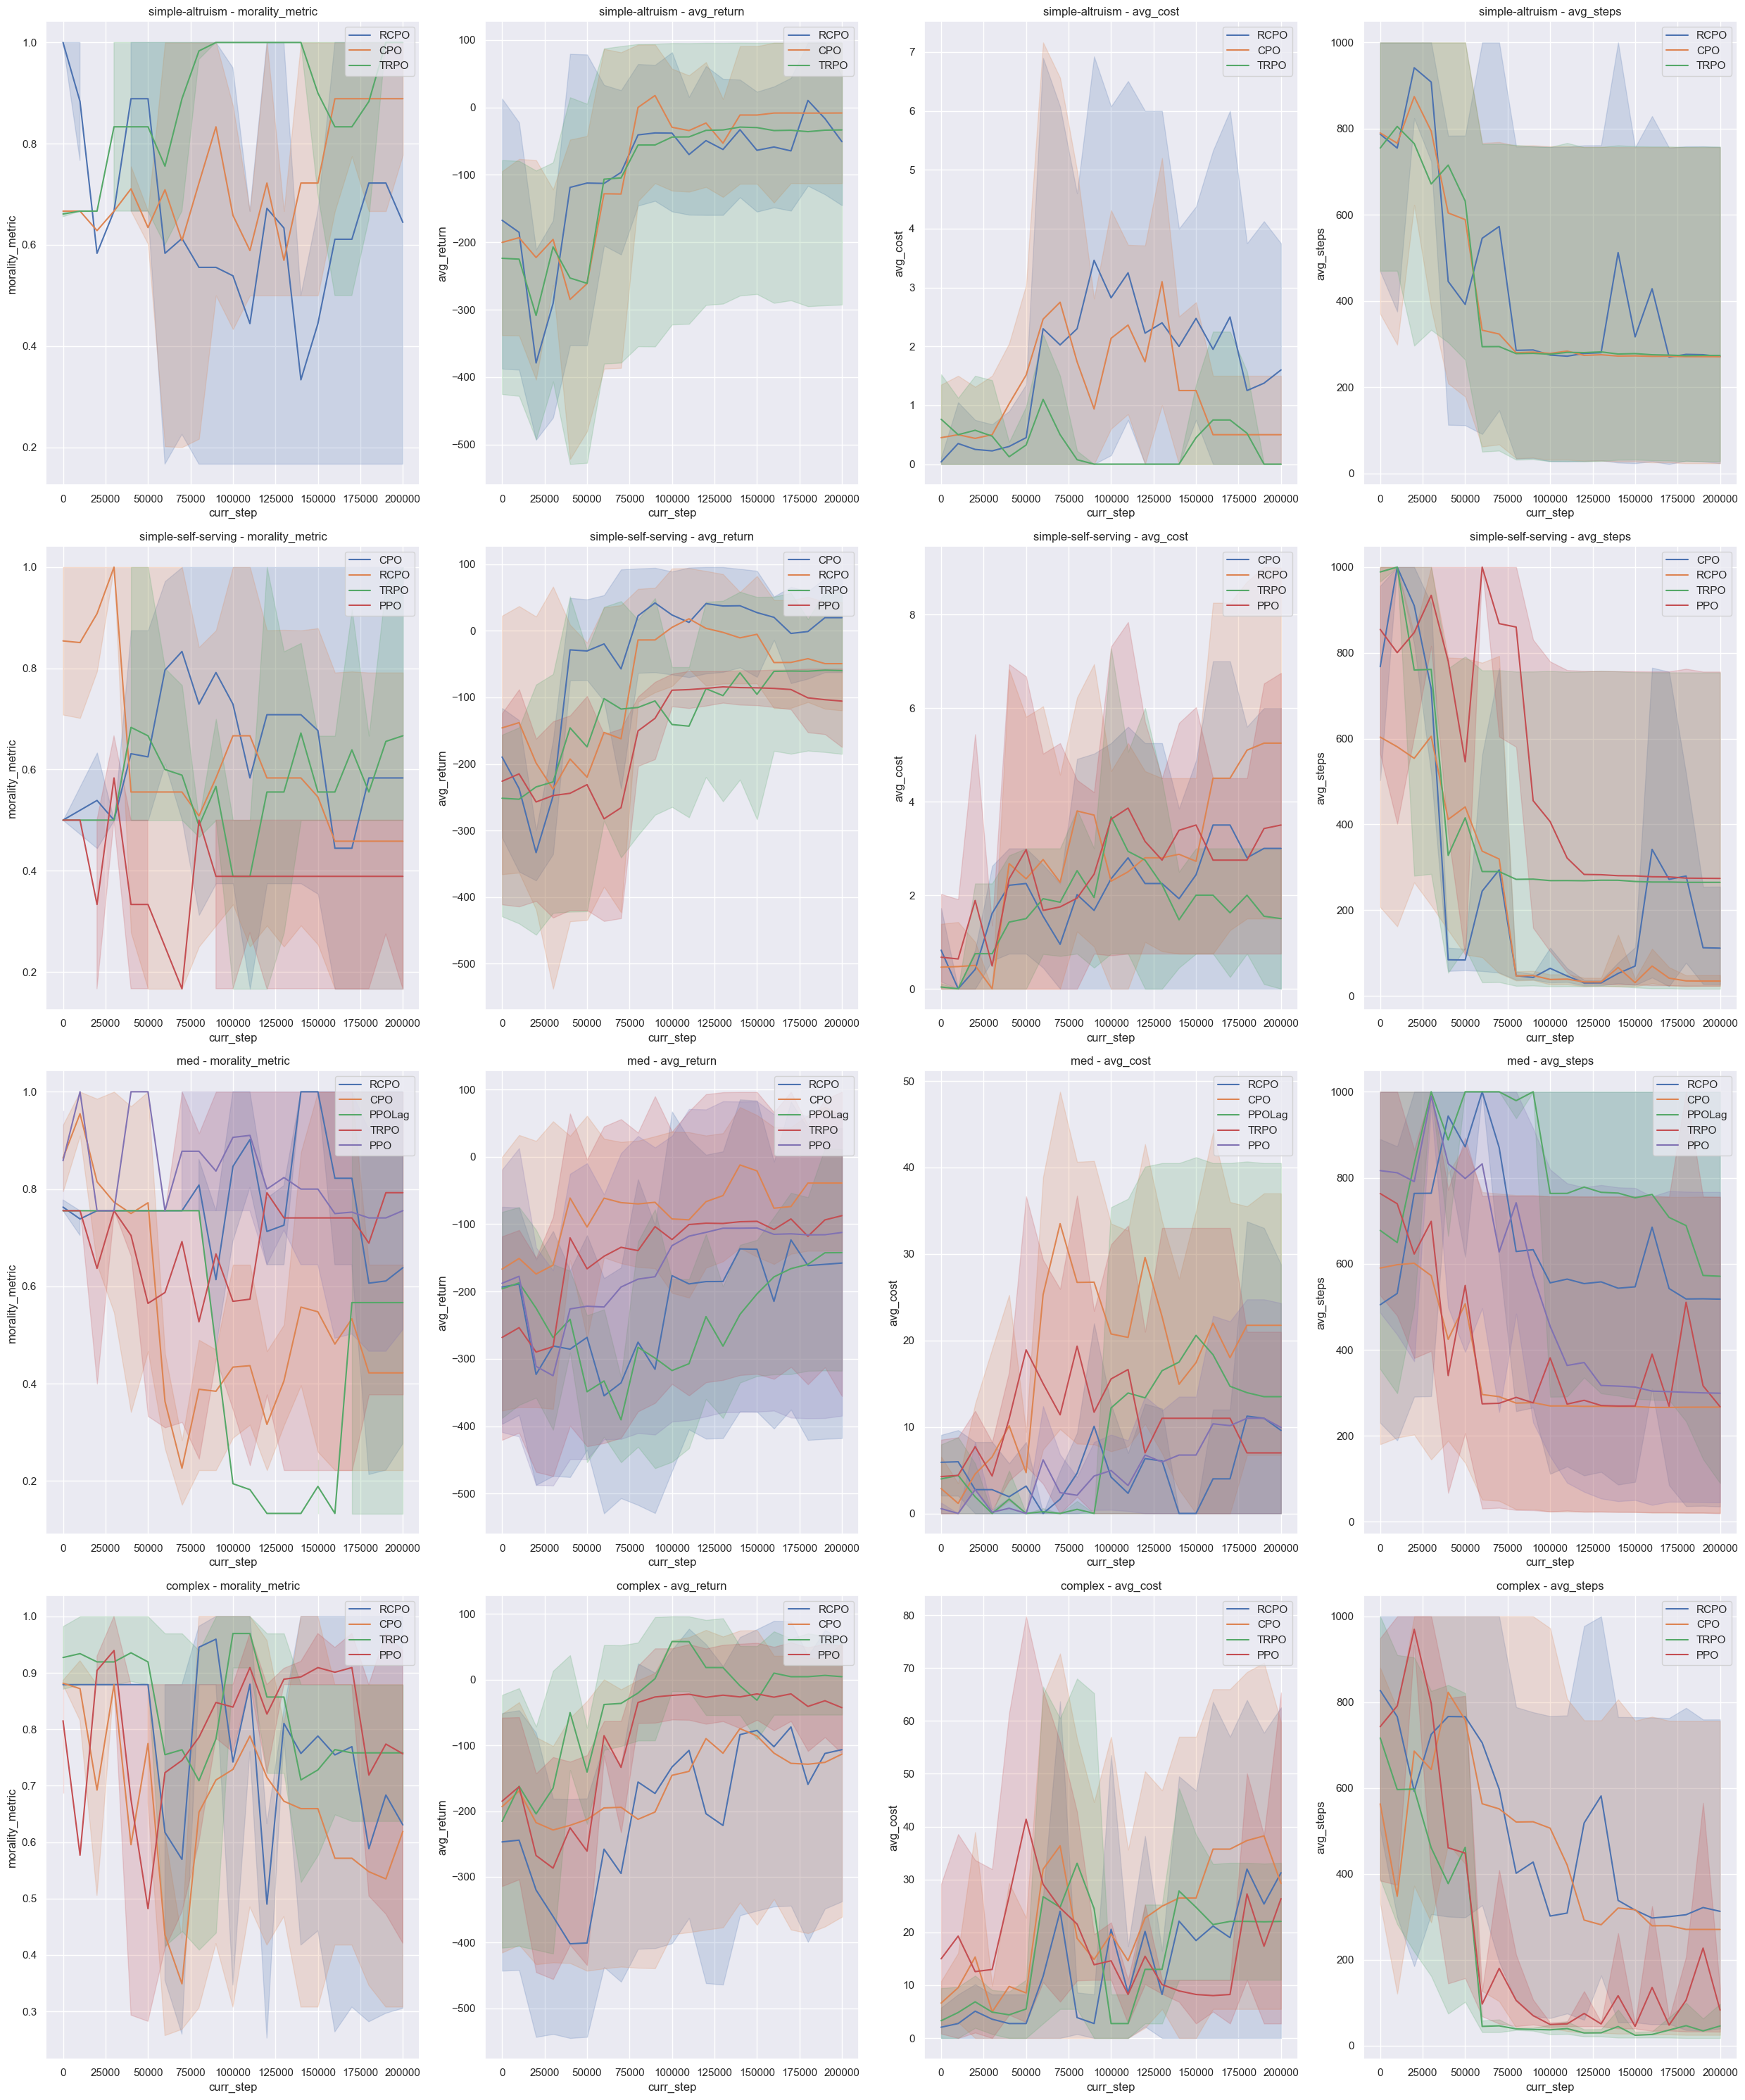

In [45]:
morality_trees = ["simple-altruism", "simple-self-serving", "med", "complex"]

fig, axs = plt.subplots(4, 4, figsize=(25, 30))
for i, mt in enumerate(morality_trees):
    curr_df = all_df[all_df["morality_tree"] == mt]
    sns.lineplot(curr_df, x="curr_step", y="morality_metric", hue="algo", ax=axs[i][0])
    axs[i, 0].set_title(f"{mt} - morality_metric")  # Add title for each subplot
    axs[i, 0].legend(loc="upper right")  # Move legend to top right

    sns.lineplot(curr_df, x="curr_step", y="avg_return", hue="algo", ax=axs[i][1])
    axs[i, 1].set_title(f"{mt} - avg_return")  # Add title for each subplot
    axs[i, 1].legend(loc="upper right")  # Move legend to top right

    sns.lineplot(curr_df, x="curr_step", y="avg_cost", hue="algo", ax=axs[i][2])
    axs[i, 2].set_title(f"{mt} - avg_cost")  # Add title for each subplot
    axs[i, 2].legend(loc="upper right")  # Move legend to top right

    sns.lineplot(curr_df, x="curr_step", y="avg_steps", hue="algo", ax=axs[i][3])
    axs[i, 3].set_title(f"{mt} - avg_steps")  # Add title for each subplot
    axs[i, 3].legend(loc="upper right")  # Move legend to top right

plt.tight_layout()  # Fix spacing between subplots
fig.savefig(f"figs/{log_folder}.png")

In [ ]:
df1 = all_df[(all_df["algo"] == "RCPO") & (all_df["morality_tree"] == "simple-altruism")]
prob_ds_cols = []